In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cp /content/drive/MyDrive/fer2013plus.zip /content/

In [ ]:
!mkdir fer2013plus/

In [ ]:
!unzip fer2013plus.zip -d /content/fer2013plus/

Streaming output truncated to the last 5000 lines.
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017527.png  
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017536.png  
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017542.png  
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017574.png  
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017577.png  
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017579.png  
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017584.png  
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017610.png  
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017616.png  
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017623.png  
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017633.png  
  inflating: /

## Defining architechure and train function


In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from collections import Counter
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


# =============================================================================
#  STEP 1 · Data loaders
#  ResNet18 expects 3-channel 224×224 input — we replicate grayscale → RGB
#  and use ImageNet normalization since that's what the pretrained weights saw
# =============================================================================
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),   # replicate to 3ch for ResNet
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(
    '/content/fer2013plus/fer2013plus/fer2013/train/', transform=transform_train)
test_dataset  = datasets.ImageFolder(
    '/content/fer2013plus/fer2013plus/fer2013/test/',  transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True)

NUM_CLASSES = len(train_dataset.classes)
print(f"Classes ({NUM_CLASSES}): {train_dataset.classes}")


# =============================================================================
#  STEP 2 · Class-weighted CE  (normalized, no label smoothing this time —
#           smoothing interacted badly with the weighted loss)
# =============================================================================
all_labels    = [y for _, y in train_dataset]
counts        = Counter(all_labels)
total         = sum(counts.values())
raw_w         = torch.tensor([total / counts[i] for i in range(NUM_CLASSES)], dtype=torch.float)
class_weights = (raw_w / raw_w.mean()).to(device)
print("Class weights:", class_weights.cpu().numpy().round(3))

criterion = nn.CrossEntropyLoss(weight=class_weights)


# =============================================================================
#  STEP 3 · Pretrained ResNet18 with custom head
#
#  Fine-tuning strategy (3 stages):
#    Stage 1 (epochs 1–8)  : freeze backbone, train head only  → fast convergence
#    Stage 2 (epochs 9–20) : unfreeze layer4, train with low LR → adapt top layers
#    Stage 3 (epochs 21+)  : unfreeze all, very low LR         → full fine-tune
# =============================================================================
def build_model(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Freeze entire backbone initially
    for param in model.parameters():
        param.requires_grad = False

    # Replace the final FC with a stronger classification head
    in_features = model.fc.in_features  # 512 for ResNet18
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes)
    )
    # Head params are unfrozen by default (new layer)
    return model


def unfreeze_layer4(model):
    """Stage 2: unfreeze the last ResNet block."""
    for param in model.layer4.parameters():
        param.requires_grad = True
    print("  → Unfroze layer4")


def unfreeze_all(model):
    """Stage 3: unfreeze everything for full fine-tuning."""
    for param in model.parameters():
        param.requires_grad = True
    print("  → Unfroze all layers")


def get_optimizer(model, stage):
    """Different LR per stage. Backbone gets 10× lower LR than head."""
    head_params = list(model.fc.parameters())
    head_ids    = {id(p) for p in head_params}

    if stage == 1:
        # Only head params are trainable
        return optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=1e-3, weight_decay=1e-4)
    elif stage == 2:
        # layer4 + head with differential LR
        layer4_params = [p for p in model.layer4.parameters() if p.requires_grad]
        return optim.AdamW([
            {'params': layer4_params,                          'lr': 1e-4},
            {'params': [p for p in head_params],               'lr': 5e-4},
        ], weight_decay=1e-4)
    else:
        # All layers, backbone at 10× lower LR than head
        backbone_params = [p for n, p in model.named_parameters()
                           if p.requires_grad and id(p) not in head_ids
                           and 'layer4' not in n]
        layer4_params   = [p for p in model.layer4.parameters() if p.requires_grad]
        return optim.AdamW([
            {'params': backbone_params,          'lr': 1e-5},
            {'params': layer4_params,            'lr': 5e-5},
            {'params': list(head_params),        'lr': 1e-4},
        ], weight_decay=1e-4)


model = build_model(NUM_CLASSES).to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in model.parameters())
print(f"Stage 1 — trainable: {trainable:,} / {total_p:,} params")


# =============================================================================
#  STEP 4 · Mixup (mild, starts from epoch 1 — safe because pretrained features
#           are already rich, unlike random init)
# =============================================================================
def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


def mixed_criterion(pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# =============================================================================
#  STEP 5 · Train / eval loops
# =============================================================================
def train_epoch(model, loader, use_mixup=True):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        if use_mixup and np.random.rand() < 0.5:
            images, y_a, y_b, lam = mixup_data(images, labels)
            loss = mixed_criterion(model(images), y_a, y_b, lam)
        else:
            loss = criterion(model(images), labels)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    correct, total, total_loss = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs  = model(images)
            loss     = F.cross_entropy(outputs, labels)
            _, preds = torch.max(outputs, 1)
            total_loss += loss.item()
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
    return correct / total, total_loss / len(loader)



Device: cuda
Classes (8): ['anger', 'contempt', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
Class weights: [0.231 3.456 2.985 0.875 0.076 0.055 0.162 0.16 ]
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 197MB/s]


Stage 1 — trainable: 133,896 / 11,310,408 params


## Training Model

In [ ]:
STAGE1_END = 8    # freeze backbone, train head only
STAGE2_END = 20   # unfreeze layer4
# Stage 3 = epoch 21 onward (full fine-tune)

best_acc   = 0.0
patience   = 12
no_improve = 0
epoch      = 0
stage      = 1

optimizer = get_optimizer(model, stage=1)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=8, eta_min=1e-5)

print("\n" + "="*70)
print("  ResNet18 fine-tuning · Stage 1: head only (epochs 1–8)")
print("  Watch: train/val loss gap should be < 0.5 from epoch 1")
print("="*70)

while True:
    ep_num = epoch + 1

    # ── Stage transitions ────────────────────────────────────────────────────
    if ep_num == STAGE2_END + 1 and stage == 2:
        pass  # already transitioned

    if ep_num == STAGE1_END + 1 and stage == 1:
        stage = 2
        unfreeze_layer4(model)
        optimizer = get_optimizer(model, stage=2)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=12, eta_min=1e-6)
        print(f"\n{'='*70}")
        print(f"  Stage 2: layer4 + head (epochs {STAGE1_END+1}–{STAGE2_END})")
        print(f"{'='*70}")

    if ep_num == STAGE2_END + 1 and stage == 2:
        stage = 3
        unfreeze_all(model)
        optimizer = get_optimizer(model, stage=3)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-7)
        best_acc   = 0.0   # reset best — full model now, fair comparison
        no_improve = 0
        print(f"\n{'='*70}")
        print(f"  Stage 3: full fine-tune (epoch {STAGE2_END+1}+)")
        print(f"{'='*70}")

    train_loss        = train_epoch(model, train_loader, use_mixup=(stage >= 2))
    val_acc, val_loss = evaluate(model, test_loader)
    scheduler.step()

    lr_now = optimizer.param_groups[-1]['lr']

    if val_acc > best_acc + 1e-4:
        best_acc   = val_acc
        no_improve = 0
        torch.save(model.state_dict(), "best_fer_resnet18.pth")
        tag = " ← best"
    else:
        no_improve += 1
        tag = ""

    gap = val_loss - train_loss
    print(f"Epoch {ep_num:03d} [S{stage}] | "
          f"TrainLoss: {train_loss:.4f} | "
          f"ValLoss: {val_loss:.4f} | "
          f"Gap: {gap:+.4f} | "
          f"ValAcc: {val_acc:.4f} | "
          f"LR: {lr_now:.1e} | "
          f"NoImprove: {no_improve}/{patience}{tag}")

    # Early stop only in stage 3 (let stages 1 & 2 always complete)
    if stage == 3 and no_improve >= patience:
        print(f"\nConverged at epoch {ep_num}. Best val acc: {best_acc:.4f}")
        break

    # Safety cap
    if ep_num >= 80:
        print("Reached max epochs.")
        break

    epoch += 1


# =============================================================================
#  Final result
# =============================================================================
model.load_state_dict(torch.load("best_fer_resnet18.pth", map_location=device))
final_acc, final_loss = evaluate(model, test_loader)
print(f"\nFinal test accuracy : {final_acc*100:.2f}%")
print(f"Final test loss     : {final_loss:.4f}")
print(f"\nBaseline was 81.0% — improvement: {(final_acc - 0.81)*100:+.2f}%")



  ResNet18 fine-tuning · Stage 1: head only (epochs 1–8)
  Watch: train/val loss gap should be < 0.5 from epoch 1
Epoch 001 [S1] | TrainLoss: 1.8347 | ValLoss: 1.4352 | Gap: -0.3996 | ValAcc: 0.4551 | LR: 9.6e-04 | NoImprove: 0/12 ← best
Epoch 002 [S1] | TrainLoss: 1.7304 | ValLoss: 1.4583 | Gap: -0.2721 | ValAcc: 0.4643 | LR: 8.6e-04 | NoImprove: 0/12 ← best
Epoch 003 [S1] | TrainLoss: 1.6776 | ValLoss: 1.3238 | Gap: -0.3538 | ValAcc: 0.4923 | LR: 6.9e-04 | NoImprove: 0/12 ← best
Epoch 004 [S1] | TrainLoss: 1.6336 | ValLoss: 1.4463 | Gap: -0.1873 | ValAcc: 0.4554 | LR: 5.1e-04 | NoImprove: 1/12
Epoch 005 [S1] | TrainLoss: 1.6083 | ValLoss: 1.4102 | Gap: -0.1981 | ValAcc: 0.4609 | LR: 3.2e-04 | NoImprove: 2/12
Epoch 006 [S1] | TrainLoss: 1.5784 | ValLoss: 1.4076 | Gap: -0.1708 | ValAcc: 0.4616 | LR: 1.5e-04 | NoImprove: 3/12
Epoch 007 [S1] | TrainLoss: 1.5737 | ValLoss: 1.3881 | Gap: -0.1856 | ValAcc: 0.4682 | LR: 4.8e-05 | NoImprove: 4/12
Epoch 008 [S1] | TrainLoss: 1.5271 | ValLoss:

  CLASSIFICATION REPORT
              precision    recall  f1-score   support

       anger     0.8010    0.7686    0.7845       644
    contempt     0.3902    0.3137    0.3478        51
     disgust     0.6364    0.4912    0.5545        57
        fear     0.6870    0.5389    0.6040       167
   happiness     0.9102    0.9212    0.9157      1827
     neutral     0.8418    0.8483    0.8450      2597
     sadness     0.6678    0.6787    0.6732       856
    surprise     0.8342    0.8611    0.8475       900

    accuracy                         0.8270      7099
   macro avg     0.7211    0.6777    0.6965      7099
weighted avg     0.8252    0.8270    0.8257      7099

Top-1 Accuracy : 82.70%
Top-2 Accuracy : 93.93%
MCC            : 0.7719  (1=perfect, 0=random, -1=inverse)
Cohen's Kappa  : 0.7719  (>0.6 substantial, >0.8 almost perfect)


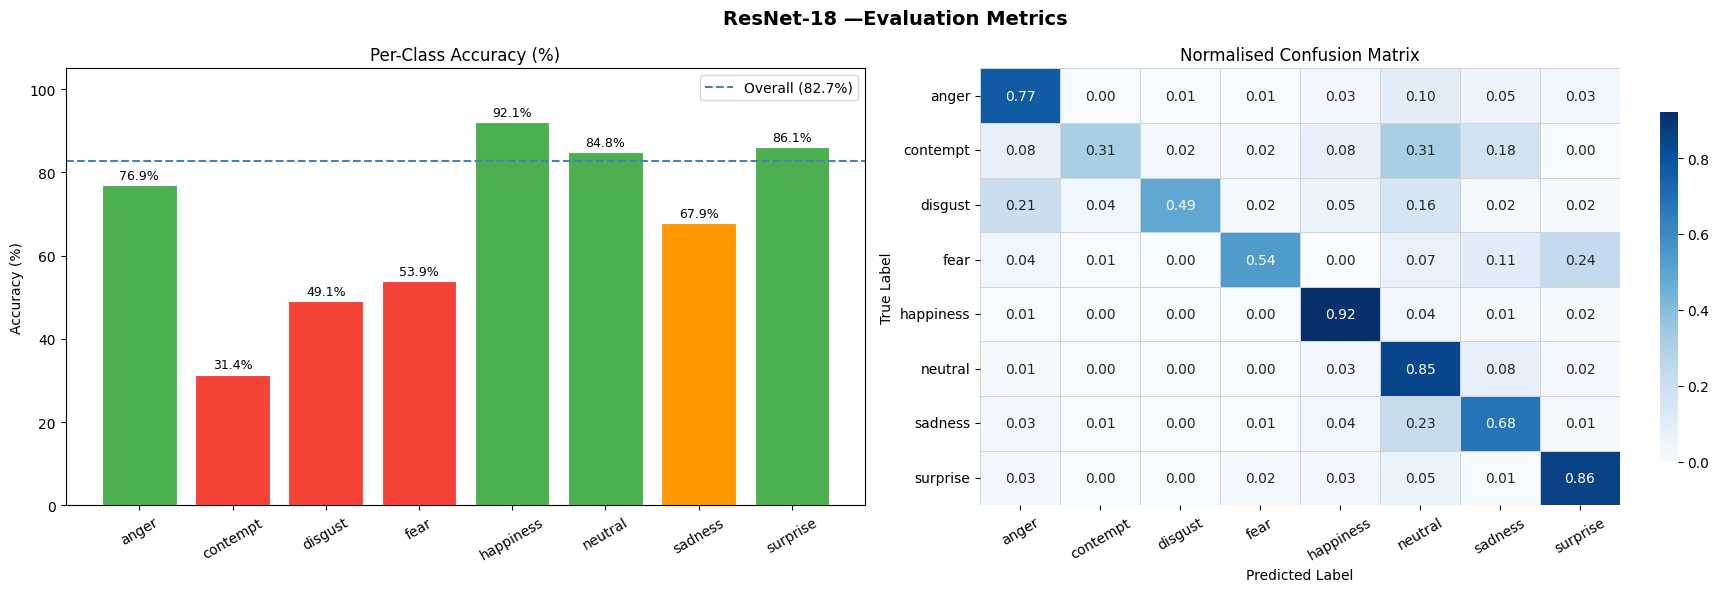


Plot saved → evaluation_metrics.png


In [ ]:
# =============================================================================
#  EVALUATION METRICS
#  Runs on the held-out test set using the best saved checkpoint.
#  Computes:
#    • Per-class Precision / Recall / F1-score  (macro + weighted averages)
#    • Confusion matrix  (raw counts + normalised)
#    • Top-1 and Top-2 accuracy
#    • Matthews Correlation Coefficient  (MCC)
#    • Cohen's Kappa
# =============================================================================
import torch, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    matthews_corrcoef, cohen_kappa_score, top_k_accuracy_score
)

# ── 1.  Collect all predictions & probabilities ──────────────────────────────
model.load_state_dict(torch.load("best_fer_resnet18.pth", map_location=device))
model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)
        preds   = torch.argmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
all_probs  = np.concatenate(all_probs)

class_names = test_loader.dataset.classes   # e.g. ['angry','disgust',...]

# ── 2.  Classification report  (per-class P / R / F1) ───────────────────────
print("=" * 70)
print("  CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(all_labels, all_preds,
                             target_names=class_names, digits=4))

# ── 3.  Top-1 and Top-2 accuracy ─────────────────────────────────────────────
top1 = (all_preds == all_labels).mean()
top2 = top_k_accuracy_score(all_labels, all_probs, k=2)
print(f"Top-1 Accuracy : {top1*100:.2f}%")
print(f"Top-2 Accuracy : {top2*100:.2f}%")

# ── 4.  MCC and Cohen's Kappa ────────────────────────────────────────────────
mcc   = matthews_corrcoef(all_labels, all_preds)
kappa = cohen_kappa_score(all_labels, all_preds)
print(f"MCC            : {mcc:.4f}  (1=perfect, 0=random, -1=inverse)")
print(f"Cohen's Kappa  : {kappa:.4f}  (>0.6 substantial, >0.8 almost perfect)")
print("=" * 70)

# ── 5.  Per-class accuracy bar chart ─────────────────────────────────────────
cm         = confusion_matrix(all_labels, all_preds)
per_class  = cm.diagonal() / cm.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("ResNet-18 —Evaluation Metrics", fontsize=14, fontweight="bold")

# Bar chart
colors = ["#4CAF50" if v >= 0.75 else "#FF9800" if v >= 0.60 else "#F44336"
          for v in per_class]
bars = axes[0].bar(class_names, per_class * 100, color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("Per-Class Accuracy (%)")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 105)
axes[0].axhline(y=top1 * 100, color="steelblue", linestyle="--", linewidth=1.5,
                label=f"Overall ({top1*100:.1f}%)")
axes[0].tick_params(axis="x", rotation=30)
for bar, val in zip(bars, per_class):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.8,
                 f"{val*100:.1f}%", ha="center", va="bottom", fontsize=9)
axes[0].legend()

# Normalised confusion matrix
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor="lightgrey", ax=axes[1],
            cbar_kws={"shrink": 0.8})
axes[1].set_title("Normalised Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")
axes[1].tick_params(axis="x", rotation=30)
axes[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("evaluation_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved → evaluation_metrics.png")
